<a href="https://colab.research.google.com/github/kerelosgerges/CNN-MODEL/blob/main/CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CNN MODEL **
-----------------------------------------------------------------





ديه الداتا اللي انا هشتغل عليها من

kaggle

وتنقسم لست انواع
1.   buildings
2.   forest
3.   glacier
4.   mountain
5.   sea
6.   street



In [ ]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


ده ال

path

بتاع الداتا
(مكان الداتا اللي هنعمل عليها تدريب واللي هنعمل ليها اختبار للموديل )

In [ ]:
trainpath = "/kaggle/input/intel-image-classification/seg_train/seg_train"
testpath = "/kaggle/input/intel-image-classification/seg_test/seg_test"
validpath = "/kaggle/input/intel-image-classification/seg_pred/seg_pred"

فيه كذه طريقة عشان نجهز الداتا وهما



1.   Manual Data Loading with Manual Preprocessing
2.   TF.data Pipeline with Automated Preprocessing
3.   ImageDataGenerator with Automated Flow from Directory
4.   image_dataset_from_directory with Manual Augmentation Pipeline

طبعا كل واحدة ليها مميزاتها وعيوبها انا هنا مستخدم الطريقة الرابعة اللي هي

image_dataset_from_directory with Manual Augmentation Pipeline

طبعا انا عامل هنا

data augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast,RandomTranslation,RandomBrightness
BATCH_SIZE = 32
IMG_SIZE = (224,224)
train_ds = tf.keras.utils.image_dataset_from_directory(trainpath,seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(testpath,seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
pred_ds = tf.keras.utils.image_dataset_from_directory(validpath,labels=None,label_mode=None,image_size=IMG_SIZE,batch_size=BATCH_SIZE,shuffle=False)
data_augmentation = tf.keras.Sequential([RandomFlip("horizontal"),
                                         RandomRotation(0.1),
                                         RandomZoom(0.1),
                                         RandomContrast(0.1),
                                         RandomBrightness(factor=0.2),
                                         RandomTranslation(0.1, 0.1)])
normalization_layer = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
pred_ds = pred_ds.map(lambda x: normalization_layer(x))
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)
pred_ds  = pred_ds.prefetch(buffer_size=AUTOTUNE)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Found 7301 files.


بعد كده انا هبدأ في تجهيز الموديل

هستعمل ال

MobileNetV2 & DenseNet121

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2


IMG_SIZE = (224,224,3)


input_layer = Input(shape=IMG_SIZE)


base_model1 = DenseNet121(weights="imagenet", include_top=False, input_tensor=input_layer)

x1 = base_model1.output
x1 = GlobalAveragePooling2D()(x1)


base_model2 = MobileNetV2(weights="imagenet", include_top=False, input_tensor=input_layer)

x2 = base_model2.output
x2 = GlobalAveragePooling2D()(x2)


merged = Concatenate()([x1, x2])


x = Dense(256, activation="relu")(merged)
x = Dropout(0.5)(x)
output = Dense(6, activation="sigmoid")(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipython-input-3026785677.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model2 = MobileNetV2(weights="imagenet", include_top=False, input_tensor=input_layer)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 9,887,110 (37.72 MB)

 Trainable params: 9,769,350 (37.27 MB)

 Non-trainable params: 117,760 (460.00 KB)

بعد كده فيه حتة ال

callback

انت ممكن تحط فيها حاجات كتيرر بس انا هشرح هنا اهم تلات حاجات مشهورة ، انت ممكن تحط اكتر من تلاتة او تلاتة بس او اتنين بس او واحدة بس او ممكن متحطش براحتك يا صديقي

--------------------------------------------------------------------------------


checkpoint_cb = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
ده زي حارس بيسجل أفضل نسخة من النموذج أثناء التدريب.

monitor="val_accuracy" → بيشوف أداء النموذج على مجموعة الاختبار الصغيرة أثناء التدريب.

save_best_only=True → يحفظ النموذج فقط لو الأداء اتحسن، يعني مش كل مرة.

mode="max" → معناها إنه يحاول يرفع الأداء لأقصى قيمة.

verbose=1 → هيكتبلك على الشاشة كل مرة يحفظ فيها النموذج.

الفائدة: لو النموذج بدأ يخطأ بعد فترة، تقدر ترجع لأفضل نسخة موجودة.

--------------------------------------------------------------------------
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

ده زي حكم توقف التدريب لما الأداء يثبت أو يتدهور.

monitor="val_loss" → بيراقب قيمة الخطأ على مجموعة الاختبار الصغيرة.

patience=5 → لو الخطأ ما اتحسنش لمدة خمس مرات متتالية، هيوقف التدريب.

restore_best_weights=True → بعد ما يوقف التدريب، يرجع النموذج لأفضل حالة كان فيها الخطأ أقل.

verbose=1 → هيكتبلك على الشاشة سبب التوقف.

الفائدة: بيمنع إهدار وقت التدريب وبيقلل فرصة النموذج إنه يبالغ في التعلّم على بيانات التدريب.

--------------------------------------------------------------------------------

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

ده زي مدرب بيقلل سرعة التعلم لو النموذج مش بيتحسن.

monitor="val_loss" → بيراقب قيمة الخطأ على مجموعة الاختبار الصغيرة.

factor=0.5 → يقلل معدل التغيير للنموذج للنصف لو الأداء ما اتحسنش.

patience=3 → لو الخطأ ما اتحسنش لمدة ثلاث مرات متتالية، يبدأ يقلل معدل التعلم.

verbose=1 → هيكتبلك على الشاشة كل مرة يغير فيها معدل التعلم.

الفائدة: بيخلي النموذج يتعلم ببطء أكبر لو وصل لنقطة صعبة، عشان يتحسن تدريجيًا بدل ما يضيع الوقت أو يخطئ.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
import matplotlib.pyplot as plt


checkpoint_cb = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)


بعد كده الخطوة اللي بعديها هبدأ ادرب الموديل


In [ ]:
history = model.fit(train_ds,validation_data=test_ds,epochs=5,callbacks=[checkpoint_cb,earlystop_cb,reduce_lr_cb])


Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7555 - loss: 0.6733   
Epoch 1: val_accuracy improved from -inf to 0.90267, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.7557 - loss: 0.6727 - val_accuracy: 0.9027 - val_loss: 0.2653 - learning_rate: 1.0000e-04
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9014 - loss: 0.2888
Epoch 2: val_accuracy improved from 0.90267 to 0.91533, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 299s 681ms/step - accuracy: 0.9014 - loss: 0.2888 - val_accuracy: 0.9153 - val_loss: 0.2575 - learning_rate: 1.0000e-04
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.9153 - loss: 0.2512
Epoch 3: val_accuracy improved from 0.91533 to 0.91833, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 298s 677ms/step - accuracy: 0.9153 - loss: 0.2512 - val_accuracy: 0.9183 - val_loss: 0.2182 - learning_rate: 1.0000e-04
Epoch 4/5
439/439 ━━━━━━━━━━━━━

بعد كده هبدأ ارسم ال

accuracy and loss

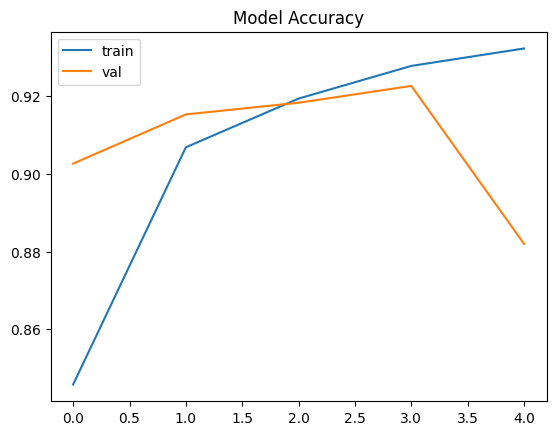

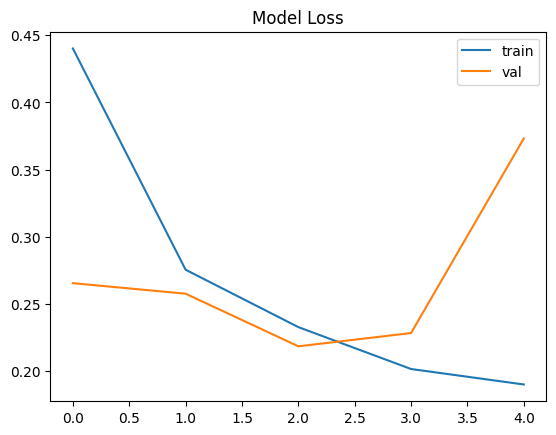

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["train","val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["train","val"])
plt.show()

بعد كده هبدأ ارسم ال

Confusion matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9187 - loss: 0.2061
Test Loss: 0.2182
Test Accuracy: 0.9183


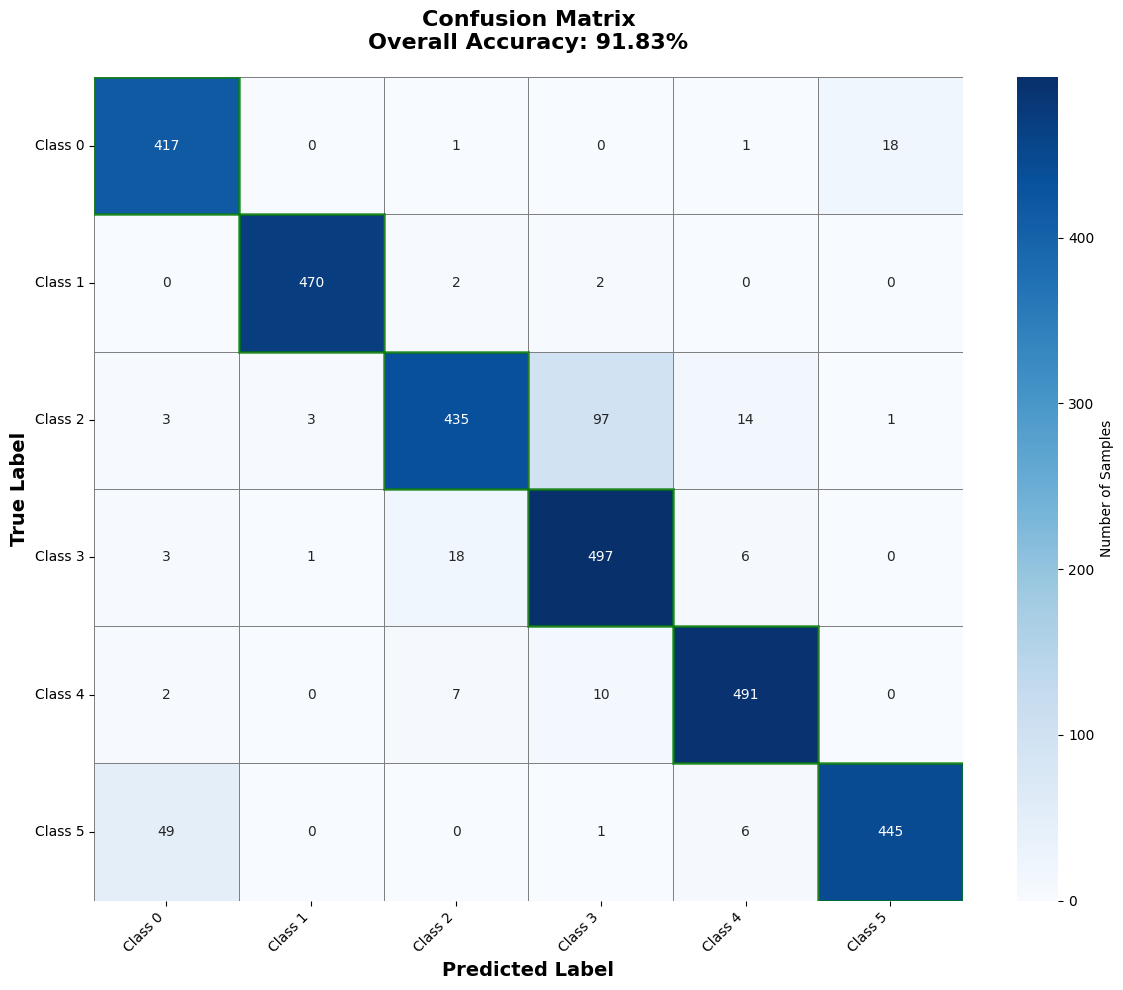


📈 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class_0     0.8797    0.9542    0.9155       437
     Class_1     0.9916    0.9916    0.9916       474
     Class_2     0.9395    0.7866    0.8563       553
     Class_3     0.8188    0.9467    0.8781       525
     Class_4     0.9479    0.9627    0.9553       510
     Class_5     0.9591    0.8882    0.9223       501

    accuracy                         0.9183      3000
   macro avg     0.9228    0.9217    0.9198      3000
weighted avg     0.9226    0.9183    0.9179      3000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
loss, acc = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
def evaluate_and_plot(model, test_ds):
    all_true = []
    all_preds = []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        true_labels = y_batch.numpy().flatten()
        pred_labels = np.argmax(preds, axis=1)
        all_true.extend(true_labels)
        all_preds.extend(pred_labels)
    y_true = np.array(all_true)
    y_pred = np.array(all_preds)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar_kws={'label': 'Number of Samples'},linewidths=0.5, linecolor='gray')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    accuracy = np.trace(cm) / np.sum(cm) * 100
    plt.title(f'Confusion Matrix\nOverall Accuracy: {accuracy:.2f}%',fontsize=16, fontweight='bold', pad=20)
    class_names = [f'Class {i}' for i in sorted(np.unique(y_true))]
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names, rotation=0)
    ax.grid(False)
    for i in range(len(cm)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,edgecolor='green', lw=2, alpha=0.7))
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60)
    print("📈 DETAILED CLASSIFICATION REPORT")
    print("="*60)
    report = classification_report(y_true, y_pred,target_names=[f'Class_{i}' for i in sorted(np.unique(y_true))],digits=4)
    print(report)
    return y_true, y_pred, cm, report
y_true, y_pred, cm, report = evaluate_and_plot(model, test_ds)

بعد كده ال

Auc- Roc

In [ ]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

all_true_labels = []
all_probabilities = []
for x_batch, y_batch in test_ds:
    all_true_labels.extend(y_batch.numpy())
    probs = model.predict(x_batch, verbose=0)
    all_probabilities.extend(probs)
y_true = np.array(all_true_labels)
y_pred_prob = np.array(all_probabilities)
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))
print('\n' + '='*60)
print(' DETAILED AUC-ROC SCORES')
print('='*60)
roc_auc_per_class = []
for i in range(n_classes):
    auc_score = roc_auc_score(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc_per_class.append(auc_score)
print('\n AUC-ROC per class:')
for i, class_name in enumerate(class_names):
    print(f'    {class_name:10s}: {roc_auc_per_class[i]:.4f}')
roc_auc_macro = np.mean(roc_auc_per_class)
print(f'\n Macro-average AUC-ROC      : {roc_auc_macro:.4f}')
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
print(f' Micro-average AUC-ROC      : {roc_auc_micro:.4f}')
try:
    roc_auc_weighted = roc_auc_score(y_true_bin, y_pred_prob, average='weighted', multi_class='ovr')
    print(f'  Weighted-average AUC-ROC  : {roc_auc_weighted:.4f}')
except:
    pass

plt.figure(figsize=(14, 10))
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b']
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'ROC curve - {class_names[i]} (AUC = {roc_auc_per_class[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=14, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curves - Multi-class Classification',
          fontsize=16, fontweight='bold', pad=20)

plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='lower right', fontsize=11, framealpha=0.95)
textstr = f'Macro-Avg AUC: {roc_auc_macro:.3f}\nMicro-Avg AUC: {roc_auc_micro:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.65, 0.15, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()
